## Exploratory Data Analysis 
This notebook explores the air quality and health impact dataset before modeling. The goal is to understand structure, check for missing values, examine the target variables, and identify early relationships between air quality vairables and health outcomes. 

In [20]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 

# this will be used for the plot displays to look good 
sns.set_theme(style = "whitegrid")

## Load Dataset
We will use this to load the raw air quality and health impact dataset from the 'data/raw' folder

In [21]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw"/ "air_quality_health_impact_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


## Dataset Overview 
Here we will check the size of the dataset and make sure it displays the column types. This helps us confirm that the dataset loaded correctly and that the variables are stroed in usable formats. 

In [22]:
df.shape

(5811, 15)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage: 681.1 KB


## Missing Values 
Before even building models, we need to check whether any columns contain missing values. Missing data can affect visualizations, regression models, and classification models. 

How to read the output: 
- '0' means the column has no missing values.
- Any number greater that '0' means that column has that many missing values.
- If the column were to have missing values, we would need to decide whether to remove those rows or fill in the missing values before modeling.

In [24]:
df.isna().sum()

RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64

In this dataset, each column shows '0' missing variables. This means that the dataset is complete for all listed variables, so we do not need to remove rows or fill missing values before continuing with the exploratory analysis. 

In [25]:
df.describe()


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2906.000000,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223,0.281191
std,1677.635538,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904,0.714075
min,1.000000,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488,0.000000
25%,1453.500000,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057,0.000000
50%,2906.000000,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000,0.000000
75%,4358.500000,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000,0.000000
max,5811.000000,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000,4.000000


## Target Variable Distribution 
This will examine the distribution of "HealthImpactClass', the categorical health impace outcome. This will help us see whether the calsses are balanced or imbalanced 
How to read the output:
- Each number represents one health impact class.
- A higher count means more rows belong to that class. 
- If one class has many more rows that the others, the dataset is imbalanced.
- Class imbalance matter because a classification model may well on the largest class while performing poorly on smaller classes. 

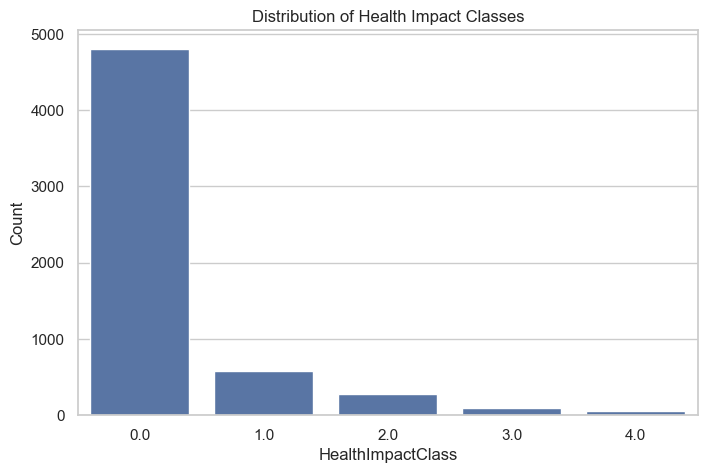

In [26]:
class_counts = df["HealthImpactClass"].value_counts().sort_index()
class_counts 
plt.figure(figsize = (8, 5))
sns.countplot(data = df, x = "HealthImpactClass", order = sorted(df["HealthImpactClass"].unique()))
plt.title("Distribution of Health Impact Classes")
plt.xlabel("HealthImpactClass")
plt.ylabel("Count")
plt.show()

The distribution shows that 'HealthImpactClass' is imbalanced, with most observations in class '0'. 

## Correlation Analysis 
This section checks which numerical variables have the strongest relationship with 'HealthImpactScore'. Correlation helps identify possible predictors for later regression models. 

How to read the output:
- Correlation calues range from '-1' to '1'. 
- A value close to '1' means a strong positive relationship. 
- A values vlose to '-1' means a strong negative relationship. 
- A value close to '0' means little or no linear relationship 
- Correlation does not prove causation; it only shows association. 

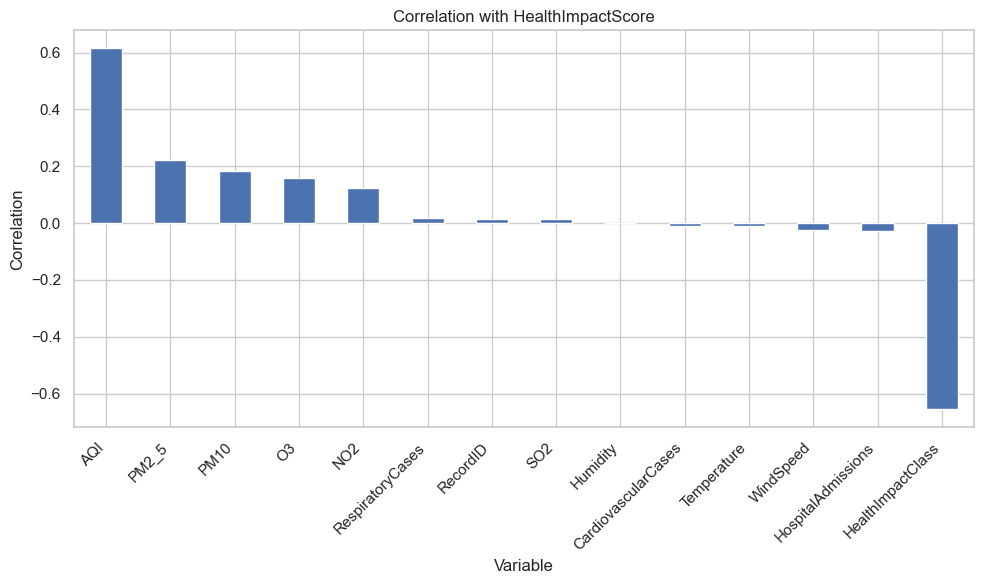

In [27]:
numeric_cols = df.select_dtypes(include=["number"]).columns

correlations = (
    df[numeric_cols]
    .corr()["HealthImpactScore"]
    .sort_values(ascending = False) 
) 

correlations
plt.figure(figsize=(10, 6))
correlations.drop("HealthImpactScore").plot(kind="bar")
plt.title("Correlation with HealthImpactScore")
plt.ylabel("Correlation")
plt.xlabel("Variable")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()


AQI has the strongest positive correlation with 'HealthImpactScore', which supports that worse air quality is associated with worse health impact outcomes. Other pollutant variables such as PM2.5, PM10, 03, N02, also show positive relationships, but they appear weaker than AQI.

## Initial Visualizations
This section uses scatter plots to examine how major air quality variables relate to 'HealthImpactScore'.

How to read the plots:

- Each point represents one record in the dataset.
- The x-axis shows the air quality variable.
- The y-axis shows 'HealthImpactScore'. 
- If points generally rise from left to right, that suggest a positive relationship. 
- If points are widely scattered, the relationship may be weak or noisy. 

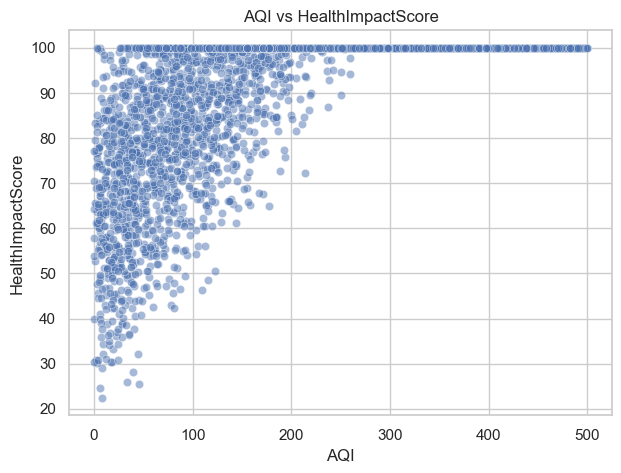

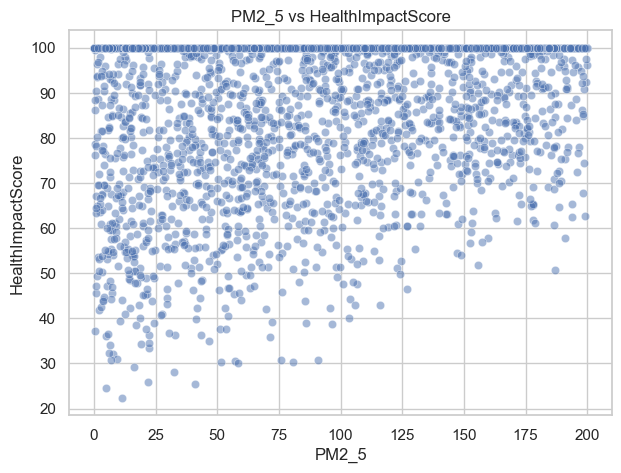

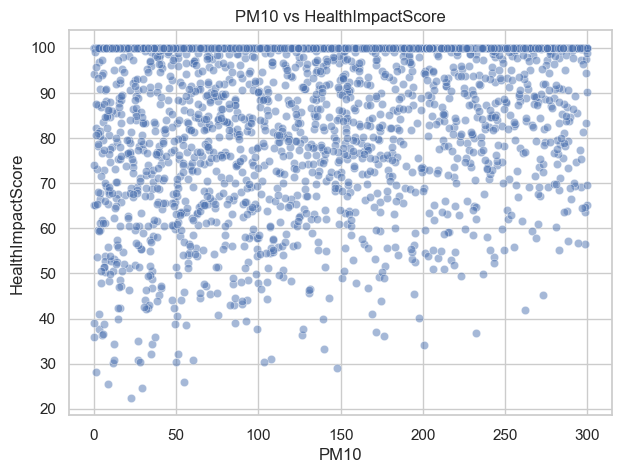

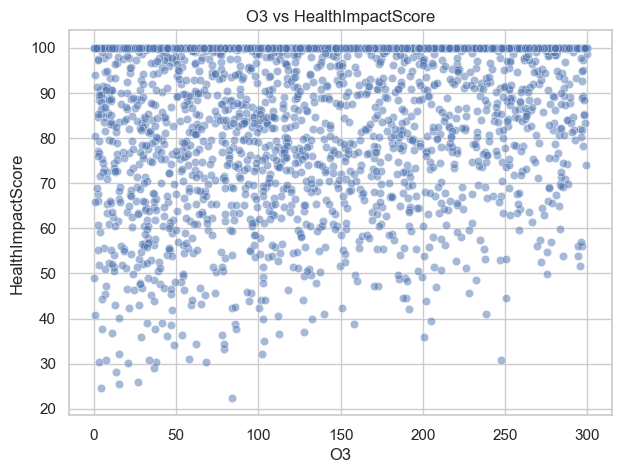

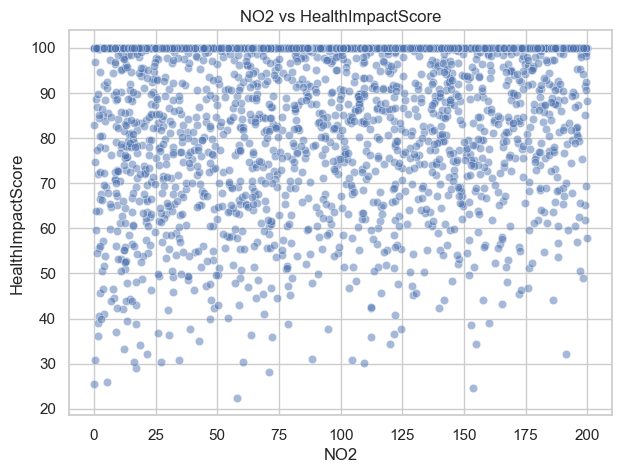

In [28]:
important_predictors = ["AQI", "PM2_5", "PM10", "O3", "NO2"]

for col in important_predictors:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data = df, x = col, y = "HealthImpactScore", alpha = 0.5)
    plt.title(f"{col} vs HealthImpactScore")
    plt.xlabel(col)
    plt.ylabel("HealthImpactScore")
    plt.show()

The scatter plots provide a visual check of the relationships between major air quality variables and 'HealthImpactScore'. AQI appears to have the clearest positive pattern, while other pollutants may still contribute useful information but show weaker visual relationships. 

## Initial Observations 
The exploratory analysis shows that the dataset has 5,811 records and 15 columns, with no missing values. The target variable "healthImpactClass' is imbalanced, with most observations in class '0'. AQI appears to have the strongest relationship with 'HealthImpactScore', while PM2.5, PM10, O3, NO2, also show weaker positive realtionships. These findings support using air quality variables as predictors in later regression and classification models. 